In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import glob
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score
import re
from sklearn.metrics import confusion_matrix
from model import SimpleSpeechCommandModel
import seaborn as sns
from data_loading import create_dataloader, COMMANDS

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class Transformer():
    pass

In [3]:
def load_model(model_path, num_classes, model_type="cnn", dropout_rate=0, **kwargs):
    if model_type == "cnn":
        model = SimpleSpeechCommandModel(num_classes=num_classes, dropout_rate=dropout_rate)
    elif model_type == "transformer":
        model = Transformer()
    else:
        raise ValueError(f"Unknown model_type: {model_type}")

    model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')))
    model.eval()
    return model

In [21]:
from sklearn.metrics import balanced_accuracy_score


def evaluate_model(model, test_loader, device):
    """ Evaluates the model on a given test dataset and computes accuracy, precision, recall, and F1-score."""
    model.to(device)
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = np.mean(np.array(all_preds) == np.array(all_labels)) * 100
    balanced_accuracy = balanced_accuracy_score(all_labels, all_preds) * 100

    precision = precision_score(all_labels, all_preds, average='macro', zero_division=1) * 100
    recall = recall_score(all_labels, all_preds, average='macro', zero_division=1) * 100
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=1) * 100

    return {
        "accuracy": accuracy,
        "balanced_accuracy": balanced_accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    }

In [22]:
def evaluate_models(model_paths, test_loader, device, model_name):
    """
    Evaluates multiple models and computes mean and standard deviation for accuracy, precision, recall, and F1-score.
    """
    metrics = {"accuracy": [], "balanced_accuracy": [], "precision": [], "recall": [], "f1_score": []}


    for model_path in model_paths:
        print(f"Evaluating {model_path} ({model_name})...")
        model = load_model(model_path, num_classes=12, model_type='cnn')
        results = evaluate_model(model, test_loader, device)

        for key in metrics.keys():
            metrics[key].append(results[key])

        print(f"Accuracy: {results['accuracy']:.2f}%, Balanced Accuracy: {results['balanced_accuracy']:.2f}%, Precision: {results['precision']:.2f}%, Recall: {results['recall']:.2f}%, F1: {results['f1_score']:.2f}%")

    final_results = {metric: (np.mean(values), np.std(values, ddof=1)) for metric, values in metrics.items()}

    return final_results

In [6]:
def load_loss_data(pattern):
    """Function for loading loss"""
    csv_files = glob.glob(pattern)
    all_data = []

    for file in csv_files:
        match = re.search(r"seed_(\d+)", file)
        seed = int(match.group(1))
        df = pd.read_csv(file, names=["train_loss", "valid_loss"], header=0)
        df["epoch"] = df.index
        df["seed"] = seed
        all_data.append(df)

    df_all = pd.concat(all_data)

    df_grouped = df_all.groupby("epoch").agg(
        train_loss_mean=("train_loss", "mean"),
        train_loss_std=("train_loss", "std"),
        valid_loss_mean=("valid_loss", "mean"),
        valid_loss_std=("valid_loss", "std")
    ).reset_index()

    return df_grouped

In [7]:
def plot_loss(df, model_name, train_color, valid_color, plot_train=True, plot_valid=True):
    """
    Function for plotting loss values.

    Parameters:
    - df: DataFrame containing loss values
    - model_name: Model name printed on legend (e.g., 'Random Flipping')
    - lr: Learning rate value
    - train_color: Color for train loss
    - valid_color: Color for validation loss
    - plot_train: Whether to plot train loss (default: True)
    - plot_valid: Whether to plot validation loss (default: True)
"""
    if plot_train:
        train_label = f"Train Loss: {model_name}"
        plt.plot(df["epoch"], df["train_loss_mean"], label=train_label, color=train_color)
        plt.fill_between(df["epoch"],
                         df["train_loss_mean"] - df["train_loss_std"],
                         df["train_loss_mean"] + df["train_loss_std"],
                         color=train_color, alpha=0.2)

    if plot_valid:
        valid_label = f"Valid Loss: {model_name}"
        plt.plot(df["epoch"], df["valid_loss_mean"], label=valid_label, color=valid_color)
        plt.fill_between(df["epoch"],
                         df["valid_loss_mean"] - df["valid_loss_std"],
                         df["valid_loss_mean"] + df["valid_loss_std"],
                         color=valid_color, alpha=0.2)

In [8]:
def generate_confusion_matrix(model_type, model_path, test_loader, save_path=None):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = load_model(model_type, model_path)
    model = model.to(device)
    model.eval()

    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=test_loader.dataset.classes, yticklabels=test_loader.dataset.classes)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')

    if save_path:
        if save_path.endswith('.csv'):
            cm_df = pd.DataFrame(cm, index=test_loader.dataset.classes, columns=test_loader.dataset.classes)
            cm_df.to_csv(save_path, index=True)
        elif save_path.endswith('.txt'):
            np.savetxt(save_path, cm, fmt='%d', delimiter='\t')
        elif save_path.endswith('.png') or save_path.endswith('.jpg'):
            plt.savefig(save_path, dpi=300)
        else:
            print("Unsupported file extension. Supported extensions: .csv, .txt, .png, .jpg.")
            return

    plt.show()

In [9]:


data_dir = "data/train"
test_loader = create_dataloader(data_dir, batch_size=32, mode='testing')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

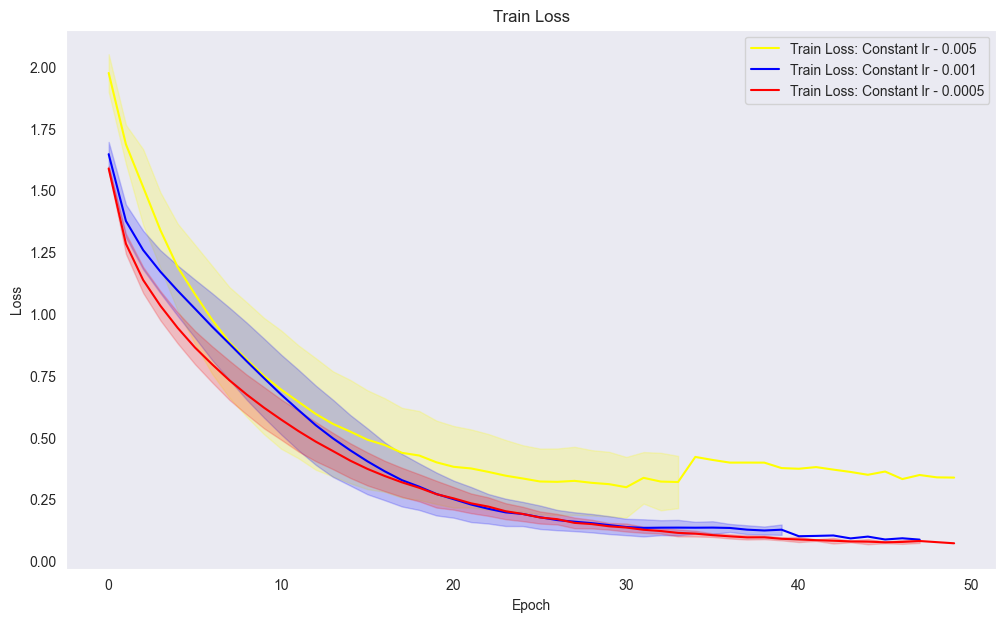

In [27]:
df_cnn_lr001 = load_loss_data("saved_losses/cnn_constant_lr_0.001_seed_*.csv")
df_cnn_lr005 = load_loss_data("saved_losses/cnn_constant_lr_0.005_seed_*.csv")
df_cnn_lr0005 = load_loss_data("saved_losses/cnn_constant_lr_0.0005_seed_*.csv")

plt.figure(figsize=(12, 7))

plot_loss(df_cnn_lr005, "Constant lr - 0.005", train_color="yellow", valid_color="yellow", plot_valid=False)
plot_loss(df_cnn_lr001, "Constant lr - 0.001", train_color="blue", valid_color="blue", plot_valid=False)
plot_loss(df_cnn_lr0005, "Constant lr - 0.0005", train_color="red", valid_color="red", plot_valid=False)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train Loss")
plt.legend()
plt.grid()
plt.savefig("plots/cnn_lr_train")
plt.show()

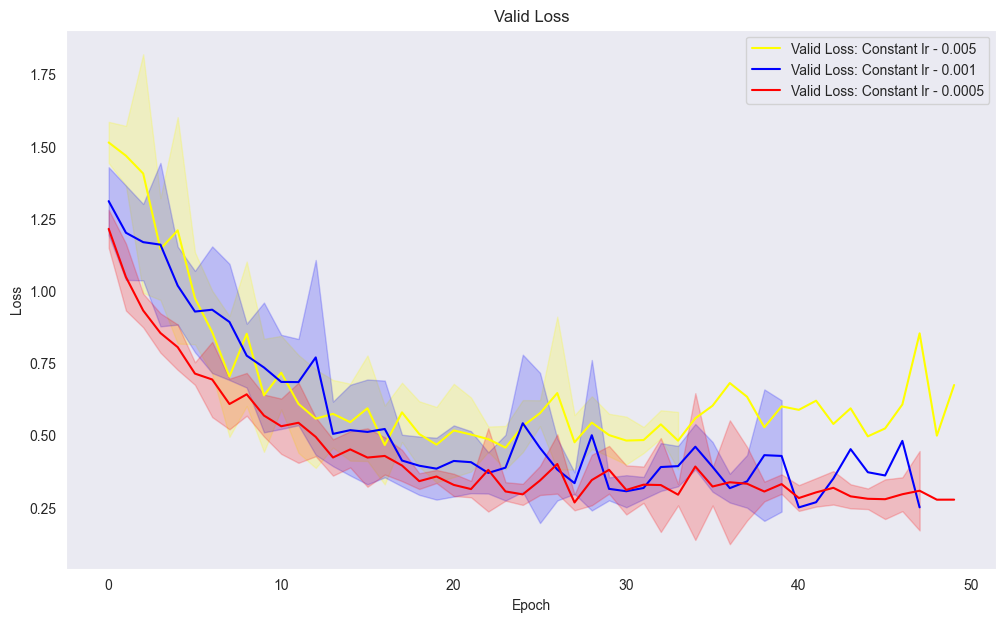

In [28]:
plt.figure(figsize=(12, 7))

plot_loss(df_cnn_lr005, "Constant lr - 0.005", train_color="yellow", valid_color="yellow", plot_train=False)
plot_loss(df_cnn_lr001, "Constant lr - 0.001", train_color="blue", valid_color="blue", plot_train=False)
plot_loss(df_cnn_lr0005, "Constant lr - 0.0005", train_color="red", valid_color="red", plot_train=False)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Valid Loss")
plt.legend()
plt.grid()
plt.savefig("plots/cnn_lr_valid")
plt.show()

In [32]:
model_paths = {
    'Constant lr - 0.005': glob.glob("saved_models/cnn_constant_lr_0.005_seed_*.pth"),
    'Constant lr - 0.001': glob.glob("saved_models/cnn_constant_lr_0.001_seed_*.pth"),
    'Constant lr - 0.0005': glob.glob("saved_models/cnn_constant_lr_0.0005_seed_*.pth"),
}

results = {}

for model_name, paths in model_paths.items():
    results[model_name] = evaluate_models(paths, test_loader, device, model_name)

for model_name, metrics in results.items():
    print(f"\n{model_name}:")
    for metric, (mean, std) in metrics.items():
        print(f"{metric.capitalize()}: {mean:.2f}% ± {std:.2f}%")

Evaluating saved_models\cnn_constant_lr_0.005_seed_1.pth (Constant lr - 0.005)...
Accuracy: 82.83%, Balanced Accuracy: 83.81%, Precision: 74.41%, Recall: 83.81%, F1: 77.55%
Evaluating saved_models\cnn_constant_lr_0.005_seed_2.pth (Constant lr - 0.005)...
Accuracy: 85.93%, Balanced Accuracy: 86.40%, Precision: 77.02%, Recall: 86.40%, F1: 80.83%
Evaluating saved_models\cnn_constant_lr_0.005_seed_3.pth (Constant lr - 0.005)...
Accuracy: 93.07%, Balanced Accuracy: 93.34%, Precision: 89.12%, Recall: 93.34%, F1: 91.12%
Evaluating saved_models\cnn_constant_lr_0.005_seed_4.pth (Constant lr - 0.005)...
Accuracy: 89.45%, Balanced Accuracy: 89.20%, Precision: 84.66%, Recall: 89.20%, F1: 86.40%
Evaluating saved_models\cnn_constant_lr_0.005_seed_5.pth (Constant lr - 0.005)...
Accuracy: 91.03%, Balanced Accuracy: 90.94%, Precision: 86.36%, Recall: 90.94%, F1: 88.25%
Evaluating saved_models\cnn_constant_lr_0.001_seed_1.pth (Constant lr - 0.001)...
Accuracy: 93.53%, Balanced Accuracy: 95.18%, Precisio

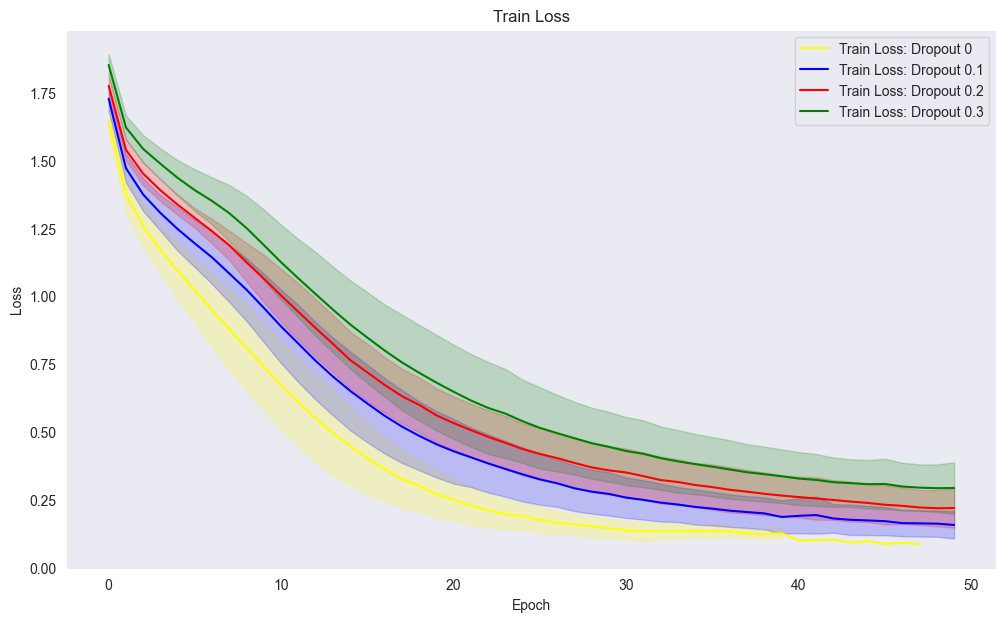

In [29]:
df_cnn_drop1 = load_loss_data("saved_losses/cnn_dropout_0.1_seed_*.csv")
df_cnn_drop2 = load_loss_data("saved_losses/cnn_dropout_0.2_seed_*.csv")
df_cnn_drop3 = load_loss_data("saved_losses/cnn_dropout_0.3_seed_*.csv")
df_cnn_drop0 = load_loss_data("saved_losses/cnn_constant_lr_0.001_seed_*.csv")

plt.figure(figsize=(12, 7))

plot_loss(df_cnn_drop0, "Dropout 0", train_color="yellow", valid_color="yellow", plot_valid=False)
plot_loss(df_cnn_drop1, "Dropout 0.1", train_color="blue", valid_color="blue", plot_valid=False)
plot_loss(df_cnn_drop2, "Dropout 0.2", train_color="red", valid_color="red", plot_valid=False)
plot_loss(df_cnn_drop3, "Dropout 0.3", train_color="green", valid_color="green", plot_valid=False)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train Loss")
plt.legend()
plt.grid()
plt.savefig("plots/cnn_drop_train")
plt.show()

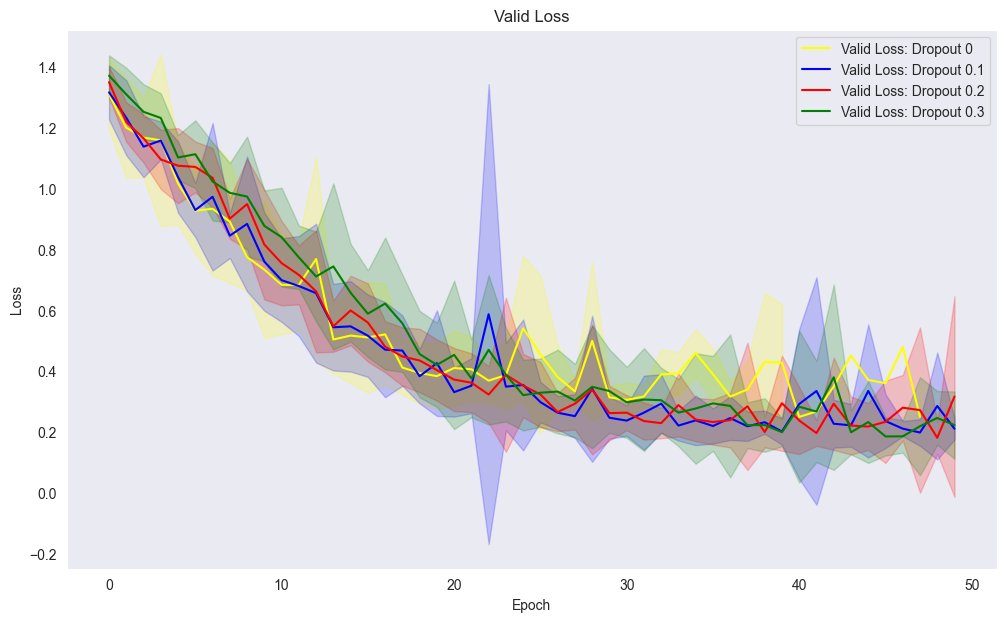

In [31]:
plt.figure(figsize=(12, 7))
plot_loss(df_cnn_drop0, "Dropout 0", train_color="yellow", valid_color="yellow", plot_train=False)
plot_loss(df_cnn_drop1, "Dropout 0.1", train_color="blue", valid_color="blue", plot_train=False)
plot_loss(df_cnn_drop2, "Dropout 0.2", train_color="red", valid_color="red", plot_train=False)
plot_loss(df_cnn_drop3, "Dropout 0.3", train_color="green", valid_color="green", plot_train=False)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Valid Loss")
plt.legend()
plt.grid()
plt.savefig("plots/cnn_drop_valid")
plt.show()

In [23]:
model_paths = {
    'Constant lr': glob.glob("saved_models/cnn_constant_lr_0.001_seed_*.pth"),
    'Dropout 0.1': glob.glob("saved_models/cnn_dropout_0.1_seed_*.pth"),
    'Dropout 0.2': glob.glob("saved_models/cnn_dropout_0.2_seed_*.pth"),
    'Dropout 0.3': glob.glob("saved_models/cnn_dropout_0.3_seed_*.pth")
}

results = {}

for model_name, paths in model_paths.items():
    results[model_name] = evaluate_models(paths, test_loader, device, model_name)

for model_name, metrics in results.items():
    print(f"\n{model_name}:")
    for metric, (mean, std) in metrics.items():
        print(f"{metric.capitalize()}: {mean:.2f}% ± {std:.2f}%")

Evaluating saved_models\cnn_constant_lr_0.001_seed_1.pth (Constant lr)...
Accuracy: 93.60%, Balanced Accuracy: 95.30%, Precision: 89.41%, Recall: 95.30%, F1: 92.16%
Evaluating saved_models\cnn_constant_lr_0.001_seed_10.pth (Constant lr)...
Accuracy: 91.18%, Balanced Accuracy: 93.27%, Precision: 86.04%, Recall: 93.27%, F1: 89.07%
Evaluating saved_models\cnn_constant_lr_0.001_seed_123.pth (Constant lr)...
Accuracy: 83.71%, Balanced Accuracy: 80.01%, Precision: 77.57%, Recall: 80.01%, F1: 77.51%
Evaluating saved_models\cnn_constant_lr_0.001_seed_2.pth (Constant lr)...
Accuracy: 91.28%, Balanced Accuracy: 92.77%, Precision: 86.28%, Recall: 92.77%, F1: 88.95%
Evaluating saved_models\cnn_constant_lr_0.001_seed_3.pth (Constant lr)...
Accuracy: 91.10%, Balanced Accuracy: 93.74%, Precision: 86.25%, Recall: 93.74%, F1: 89.41%
Evaluating saved_models\cnn_constant_lr_0.001_seed_4.pth (Constant lr)...
Accuracy: 89.38%, Balanced Accuracy: 93.30%, Precision: 82.73%, Recall: 93.30%, F1: 87.11%
Evaluat

In [34]:
def compute_confusion_matrix(model, data_loader):
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in data_loader:
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    return cm

def plot_confusion_matrix(cm, class_names):
    class_names = class_names + ['silence', 'unknown']
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

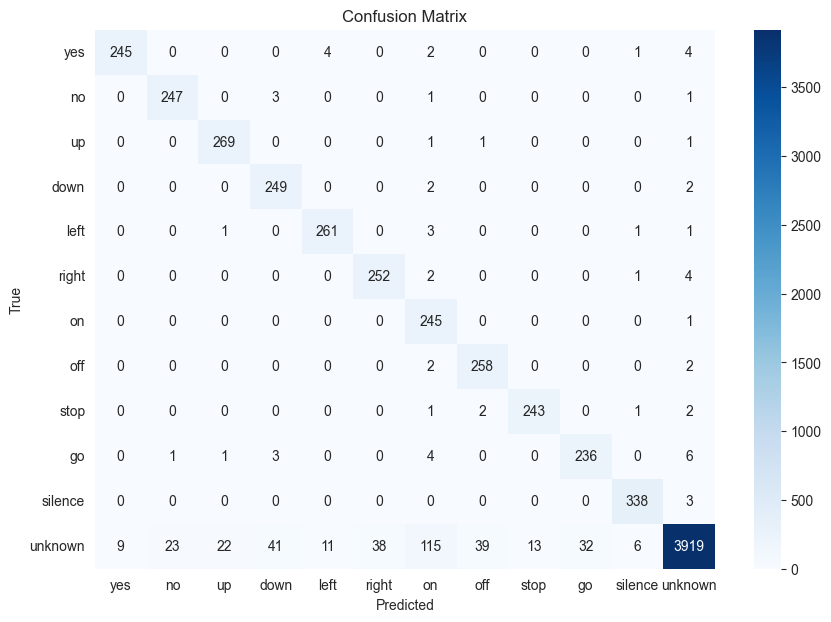

In [35]:
model_path = 'saved_models/cnn_constant_lr_0.0005_seed_5.pth'
model = load_model(model_path, num_classes=12)
cm = compute_confusion_matrix(model, test_loader)
plot_confusion_matrix(cm, class_names=COMMANDS)

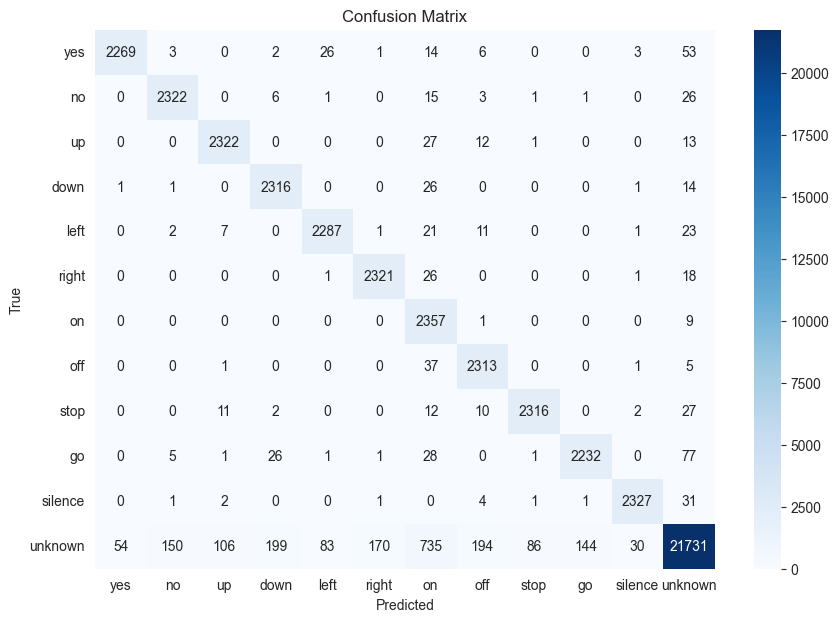

In [36]:
train_loader = create_dataloader(data_dir, batch_size=32, mode='train')
model_path = 'saved_models/cnn_constant_lr_0.0005_seed_5.pth'
model = load_model(model_path, num_classes=12)
cm = compute_confusion_matrix(model, train_loader)
plot_confusion_matrix(cm, class_names=COMMANDS)

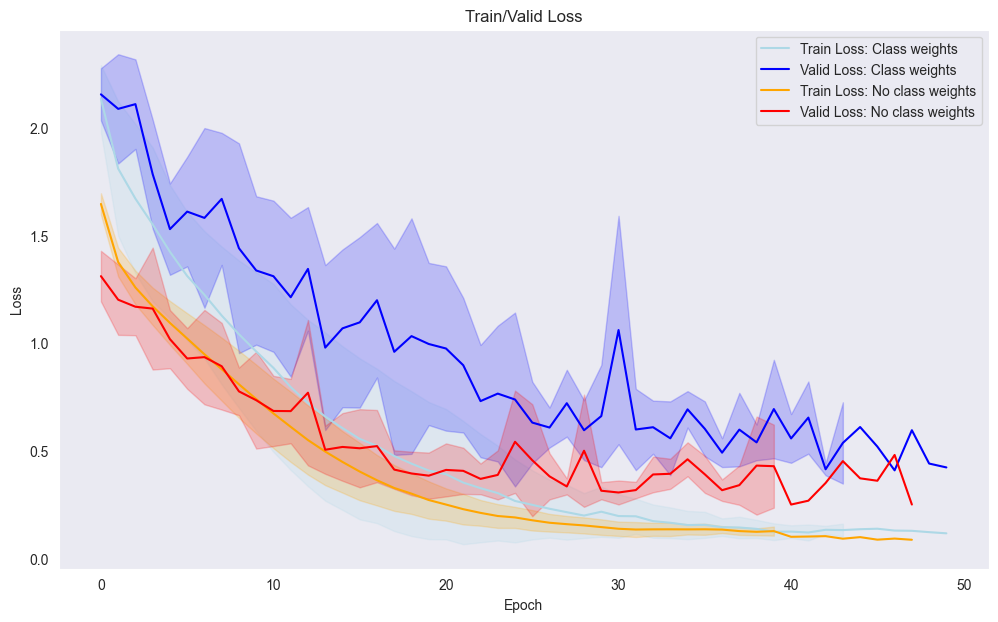

In [46]:
df_cnn_weights = load_loss_data("saved_losses/cnn_class_weights_seed_*.csv")


plt.figure(figsize=(12, 7))

plot_loss(df_cnn_weights, "Class weights", train_color="lightblue", valid_color="blue")
plot_loss(df_cnn_lr001, "No class weights", train_color="orange", valid_color="red")


plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train/Valid Loss")
plt.legend()
plt.grid()
plt.savefig("plots/cnn_weights")
plt.show()

In [47]:
model_paths = {
    'Class weights': glob.glob("saved_models/cnn_class_weights_seed_*.pth"),
}

results = {}

for model_name, paths in model_paths.items():
    results[model_name] = evaluate_models(paths, test_loader, device, model_name)

for model_name, metrics in results.items():
    print(f"\n{model_name}:")
    for metric, (mean, std) in metrics.items():
        print(f"{metric.capitalize()}: {mean:.2f}% ± {std:.2f}%")

Evaluating saved_models\cnn_class_weights_seed_1.pth (Class weights)...
Accuracy: 90.65%, Balanced Accuracy: 95.38%, Precision: 84.40%, Recall: 95.38%, F1: 89.16%
Evaluating saved_models\cnn_class_weights_seed_2.pth (Class weights)...
Accuracy: 86.75%, Balanced Accuracy: 95.06%, Precision: 78.70%, Recall: 95.06%, F1: 85.39%
Evaluating saved_models\cnn_class_weights_seed_3.pth (Class weights)...
Accuracy: 85.67%, Balanced Accuracy: 94.10%, Precision: 78.99%, Recall: 94.10%, F1: 84.58%
Evaluating saved_models\cnn_class_weights_seed_4.pth (Class weights)...
Accuracy: 87.47%, Balanced Accuracy: 96.74%, Precision: 78.49%, Recall: 96.74%, F1: 86.02%

Class weights:
Accuracy: 87.64% ± 2.14%
Balanced_accuracy: 95.32% ± 1.09%
Precision: 80.15% ± 2.84%
Recall: 95.32% ± 1.09%
F1_score: 86.29% ± 2.00%
